# Health Insurance Pricing Case: Clustering and Linear Regression Comparison

## Business Problem

A health insurance company needs better analytical support to define how much to charge for its health plans.

The pricing decision must balance two business goals:

- charge enough to reduce the risk of financial losses;
- remain attractive enough to support customer acquisition.

This project investigates whether different analytical approaches can help explain customer risk and support more informed premium-setting decisions.


## Project Objective

This project compares two approaches for solving the same health insurance pricing case:

1. a clustering-based approach, rebuilt from the completed health insurance case;
2. a linear regression approach, using multiple regression and model refinement through stepwise AIC evaluation.

The goal is to evaluate how each method performs on unseen data and how useful each one is for pricing decisions.


## Analytical Strategy

To ensure a fair comparison, both approaches will be evaluated under the same logic:

1. split the historical dataset into 80% training data and 20% test data;
2. rebuild the clustering workflow using the training set;
3. evaluate clustering on the holdout set and on 3 new incoming clients;
4. rebuild the case with linear regression using the same train-test split logic;
5. compare the predictive behavior, interpretability, and business usefulness of both approaches.


## Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import joblib


In [10]:
# =========================================
# Notebook configuration
# =========================================

RANDOM_STATE = 1

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

## Data Loading

In [11]:
# =========================================
# Reading csv file
# =========================================
base_health_insurance_df = pd.read_csv("../data/base_health_insurance.csv",sep = ";")
display(base_health_insurance_df.head()) 

,age,gender,bmi,children,discount_eligibility,region,expenses,premium
0,19,female,"24,1",0,yes,south,"1483,21","1744,95"
1,18,male,"23,5",1,no,southeast,"2237,61","2632,48"
2,28,male,33,3,no,southeast,"2046,09","2728,12"
3,33,male,"23,3",0,no,midwest,"2331,69","2743,17"
4,32,male,"23,4",0,no,midwest,"1942,5","2285,3"


## Data Validation

In [12]:
# =========================================
# checking data types and missing values
# =========================================

print(base_health_insurance_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   1338 non-null   int64
 1   gender                1338 non-null   str  
 2   bmi                   1338 non-null   str  
 3   children              1338 non-null   int64
 4   discount_eligibility  1338 non-null   str  
 5   region                1338 non-null   str  
 6   expenses              1338 non-null   str  
 7   premium               1338 non-null   str  
dtypes: int64(2), str(6)
memory usage: 83.8 KB
None


## Data Adjustment

Before proceeding with analysis, certain variables require type correction to ensure they are in the appropriate format for computation.

During data validation, it was identified that `bmi`, `expenses`, and `premium` were loaded as strings. Comma separators are replaced and the columns are converted to their correct numeric types. The `discount_eligibility` column is also encoded as a binary variable to enable its use in clustering.

In [13]:
# =========================================
# Data Adjustment
# =========================================

base_health_insurance_df["bmi"] = base_health_insurance_df["bmi"].str.replace(",", ".").astype(float) # replacing comma separator and converting bmi to float

base_health_insurance_df["expenses"] = base_health_insurance_df["expenses"].str.replace(",", ".").astype(float) # replacing comma separator and converting expenses to float

base_health_insurance_df["premium"] = base_health_insurance_df["premium"].str.replace(",", ".").astype(float) # replacing comma separator and converting premium to float

base_health_insurance_df["discount_eligibility_binary"] = np.where(
    base_health_insurance_df["discount_eligibility"] == "yes", 1, 0) # encoding discount eligibility as binary: 1 = yes, 0 = no

display(base_health_insurance_df["discount_eligibility"].unique()) # verifying unique values of original column

print(base_health_insurance_df.info()) # confirming updated data types


<StringArray>
['yes', 'no']
Length: 2, dtype: str

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          1338 non-null   int64  
 1   gender                       1338 non-null   str    
 2   bmi                          1338 non-null   float64
 3   children                     1338 non-null   int64  
 4   discount_eligibility         1338 non-null   str    
 5   region                       1338 non-null   str    
 6   expenses                     1338 non-null   float64
 7   premium                      1338 non-null   float64
 8   discount_eligibility_binary  1338 non-null   int64  
dtypes: float64(3), int64(3), str(3)
memory usage: 94.2 KB
None


## Train-Test Split (80/20)

To evaluate model performance on unseen data, the dataset is split into two subsets:

- **Training set (80%)**: used to fit the models and learn patterns from historical data.
- **Test set (20%)**: kept separate and used only for out-of-sample evaluation.

This separation helps reduce optimistic bias and provides a more realistic estimate of how the approach may perform in real pricing decisions.


In [14]:
from sklearn.model_selection import train_test_split  # function to split data into train and test sets

# splitting the full dataset: 80% for training and 20% for testing
base_health_insurance_train_df, base_health_insurance_test_df = train_test_split(
    base_health_insurance_df,  # source dataframe to split
    train_size=0.80,  # proportion for training set
    random_state=RANDOM_STATE,  # ensures reproducible split
    shuffle=True  # randomly shuffles rows before splitting
)

# resetting index in the training dataframe to keep a clean sequential index
base_health_insurance_train_df = base_health_insurance_train_df.reset_index(drop=True)  # drop old index

# resetting index in the test dataframe to keep a clean sequential index
base_health_insurance_test_df = base_health_insurance_test_df.reset_index(drop=True)  # drop old index

print("Train shape:", base_health_insurance_train_df.shape)  # shows training rows and columns
print("Test shape:", base_health_insurance_test_df.shape)  # shows test rows and columns



Train shape: (1070, 9)
Test shape: (268, 9)


## Clustering Modeling

In this section, the clustering approach is implemented to solve the health insurance pricing case.

The objective is to identify groups of clients with similar risk and cost behavior, so the company can support pricing decisions with a segmented view of the portfolio.

The workflow in this section will include:

- selecting the variables used for clustering;
- standardizing the selected variables to make them comparable;
- defining the number of clusters;
- fitting the clustering model on the training set;
- interpreting cluster profiles in business terms.


## Feature Selection

For the clustering process, the following variables were selected:

- Age  
- BMI  
- Number of children  
- Discount eligibility (to be encoded as binary: 0 = no, 1 = yes)

These variables were chosen because they represent key demographic and behavioral factors that directly influence health risk and, consequently, medical costs.

Age and BMI are strong indicators of health condition and risk exposure.  
The number of children may impact healthcare usage and financial pressure on insurance plans.  
Discount eligibility reflects policy-related segmentation that may influence pricing and customer grouping.

Together, these variables provide a meaningful representation of customer profiles, enabling the identification of distinct clusters for pricing strategy optimization.


In [15]:
# =========================================
# Selecting columns for clustering (training set only)
# =========================================

cluster_columns = ["age", "bmi", "children", "discount_eligibility_binary"]  # variables used in clustering
cluster_train_df = base_health_insurance_train_df[cluster_columns].copy()  # selecting only train rows and clustering columns

display(cluster_train_df.head())  # preview of clustering input (train set)


,age,bmi,children,discount_eligibility_binary
0,53,26.6,0,0
1,53,21.4,1,0
2,18,20.4,0,0
3,60,24.0,0,0
4,45,33.7,1,0


## Data Standardization

Before clustering, all variables must be on the same scale.  
Without standardization, variables with larger ranges (like age) would dominate the distance calculations used by K-Means, producing biased clusters.

StandardScaler transforms each variable to have mean = 0 and standard deviation = 1.

In [16]:
# =========================================
# Data standardization (training set only)
# =========================================

scaler = StandardScaler()  # creating the scaler object
cluster_train_scaled = scaler.fit_transform(cluster_train_df)  # fitting scaler on train data and transforming train data
cluster_train_scaled_df = pd.DataFrame(  # converting scaled array back to dataframe
    cluster_train_scaled,  # scaled numeric values from training set
    columns=cluster_train_df.columns  # preserving original column names
)

display(cluster_train_scaled_df.head())  # preview of standardized training data


,age,bmi,children,discount_eligibility_binary
0,1.002286,-0.251537,-0.907058,-0.508747
1,1.002286,-1.066747,-0.078942,-0.508747
2,-1.504266,-1.223518,-0.907058,-0.508747
3,1.503597,-0.659142,-0.907058,-0.508747
4,0.429360,0.861538,-0.078942,-0.508747


## Elbow Method

To apply K-Means, we need to decide how many clusters (K) best represent the data.
The Elbow Method helps by running K-Means for a range of K values and measuring the inertia —
the sum of squared distances between each point and its assigned centroid.

As K increases, inertia always decreases. The optimal K is the point where the reduction
starts to flatten, forming an "elbow" in the curve. Beyond that point, adding more clusters
brings diminishing returns.


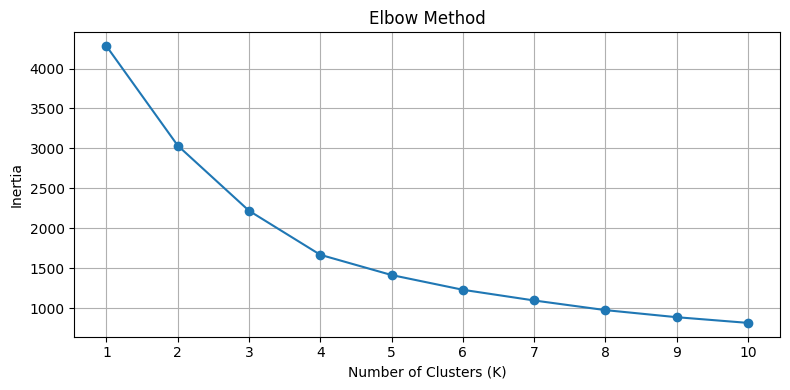

In [17]:
# =========================================
# Elbow Method (training set only)
# =========================================

inertia = []  # list to store inertia values for each tested K
n_clusters = range(1, 11)  # testing K values from 1 to 10

for n in n_clusters:  # looping through each candidate number of clusters
    kmeans_model = KMeans(  # creating a KMeans model for the current K
        n_clusters=n,  # current number of clusters being tested
        random_state=RANDOM_STATE,  # ensuring reproducible centroid initialization
        n_init=10  # running KMeans with 10 different initializations
    )
    kmeans_model.fit(cluster_train_scaled_df)  # fitting model on standardized training data
    inertia.append(kmeans_model.inertia_)  # saving within-cluster sum of squares (inertia)

plt.figure(figsize=(8, 4))  # creating figure with defined size
plt.plot(n_clusters, inertia, marker='o')  # plotting inertia against K
plt.title('Elbow Method')  # setting chart title
plt.xlabel('Number of Clusters (K)')  # labeling x-axis
plt.ylabel('Inertia')  # labeling y-axis
plt.xticks(list(n_clusters))  # forcing x-axis ticks to show each tested K
plt.grid(True)  # adding grid to improve readability
plt.tight_layout()  # adjusting spacing to avoid overlap
plt.show()  # rendering the chart


## Choosing the Number of Clusters

After applying the Elbow Method, the inertia curve was plotted for K values ranging from 2 to 10.

The curve shows a clear inflection point at K=4, where the rate of inertia reduction slows significantly. Beyond this point, adding more clusters brings diminishing returns in compactness.

Therefore, K=4 was selected as the optimal number of clusters for this analysis.


## K-Means Clustering

With the optimal number of clusters defined as K=4, the K-Means algorithm is applied to the standardized dataset.

K-Means works by iteratively assigning each observation to the nearest centroid and recalculating centroids until convergence. The result is a set of cluster labels, one for each customer in the dataset.

The parameter `n_init=50` defines how many times the algorithm is run with different random centroid initializations. Because K-Means is sensitive to the starting positions of centroids, running it multiple times and keeping the best result reduces the risk of converging to a local minimum. A higher value of `n_init` increases the chance of finding a globally optimal solution at the cost of additional computation time.

These labels will be used in the next step to profile each cluster and extract business insights.


In [ ]:
# =========================================
# K-Means Clustering - training the K-Means model (training set only)
# =========================================

kmeans_model = KMeans(
    n_clusters=4,  # using the selected number of clusters from elbow analysis
    random_state=RANDOM_STATE,  # ensuring reproducible clustering results
    n_init=50  # running K-Means with multiple initializations for stable convergence
)
kmeans_model.fit(cluster_train_scaled_df)  # fitting K-Means on standardized training data only
